In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import ndarray
from pandas import DataFrame

from sklearn.feature_selection import VarianceThreshold

# EDA

In [2]:
df: DataFrame = pd.read_excel("data.xlsx")
df.drop(columns = [col for col in df.columns if "Unnamed" in col], inplace = True)

print(f"Shape: {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (1001, 213)
Duplicates: 32
Missing values: 36


## Распределения признаков и таргетов

Проверим распределение таргетов

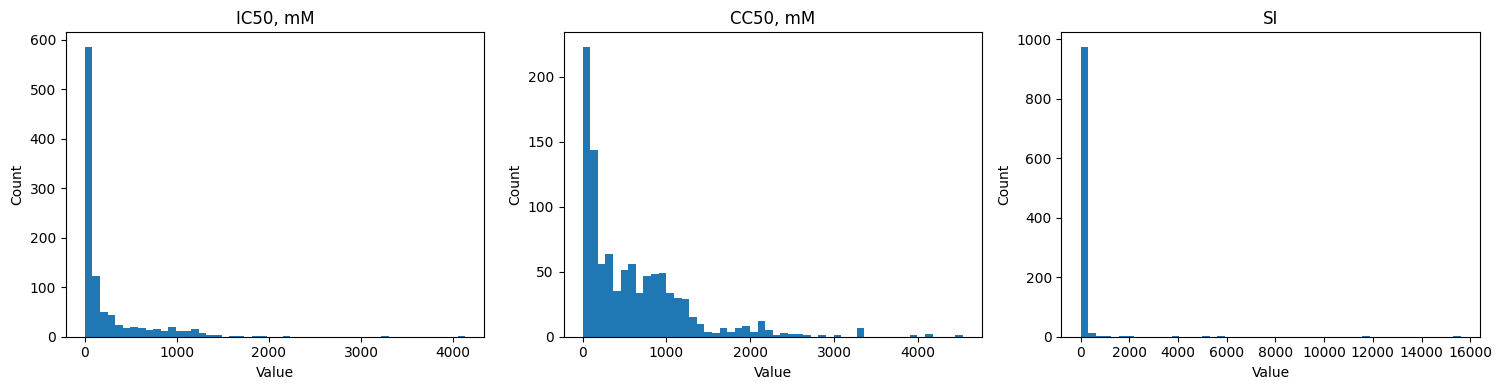

In [3]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

axes[0].hist(df["IC50, mM"], bins = 50)
axes[0].set_title("IC50, mM")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(df["CC50, mM"], bins = 50)
axes[1].set_title("CC50, mM")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

axes[2].hist(df["SI"], bins = 50)
axes[2].set_title("SI")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("graphs/target_distributions.png", dpi = 150)
plt.show()

Видим сильное смещение распределения к нулю, с довольно длинными хвостами (вроде вполне логично, что какие-то соединения сильно активнее).

Посмотрим на логарифмы таргетов:

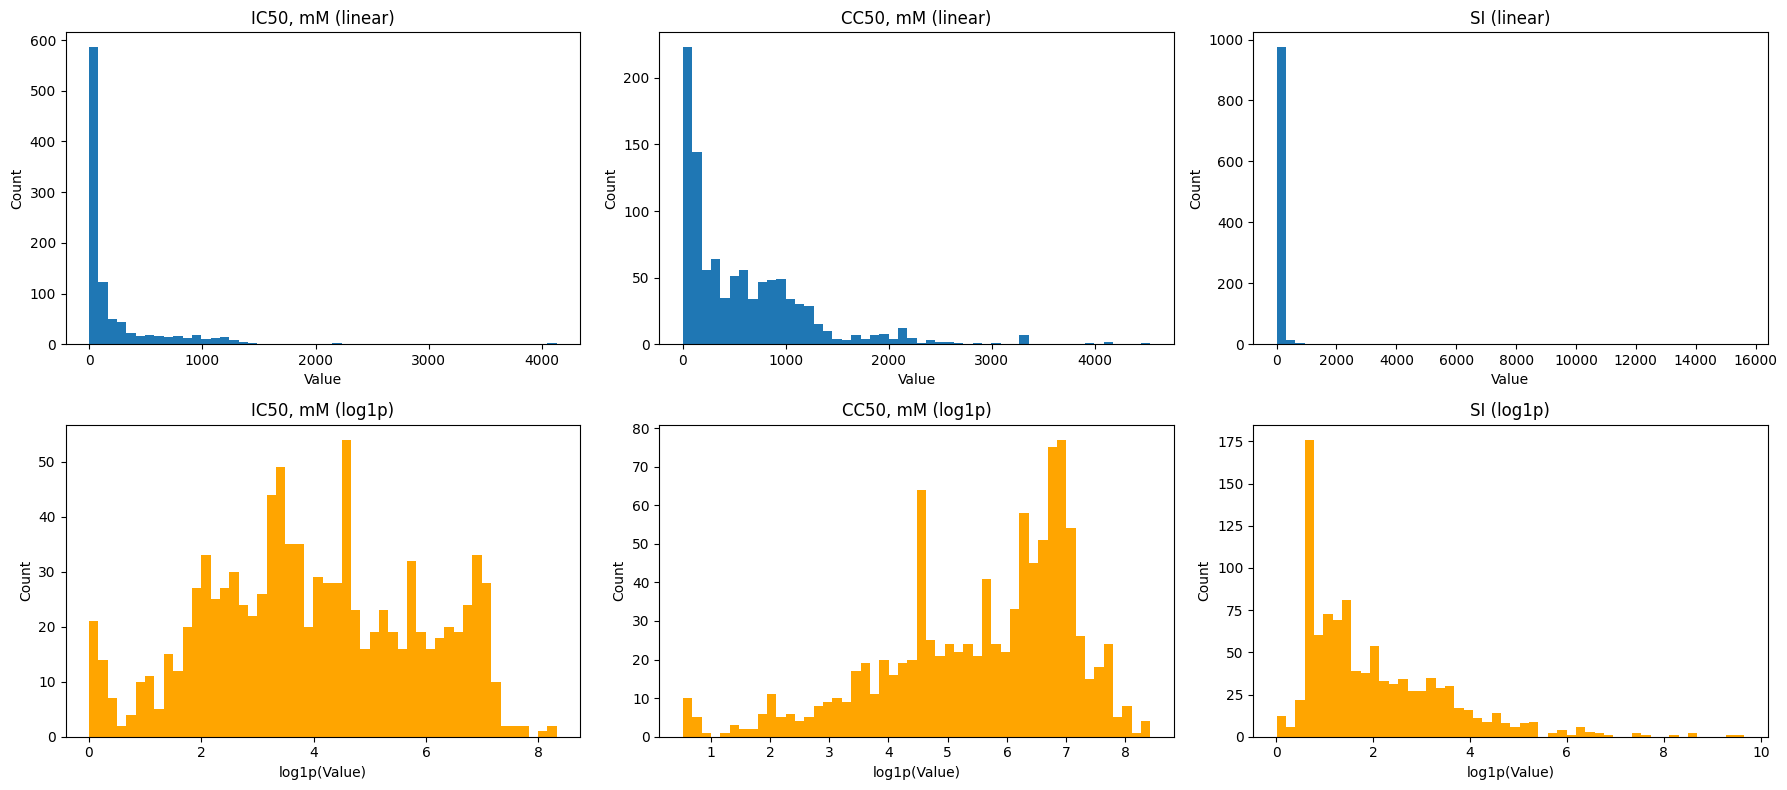


Statistics for log-transformed targets:

IC50, mM:
  Original - mean: 222.81, std: 402.17, skew: 3.67
  Log1p    - mean: 3.98, std: 1.86, skew: -0.03

CC50, mM:
  Original - mean: 589.11, std: 642.87, skew: 1.97
  Log1p    - mean: 5.57, std: 1.59, skew: -0.91

SI:
  Original - mean: 72.51, std: 684.48, skew: 18.01
  Log1p    - mean: 2.04, std: 1.46, skew: 1.43


In [4]:
fig, axes = plt.subplots(2, 3, figsize = (18, 8))

targets: list[str] = ["IC50, mM", "CC50, mM", "SI"]
titles: list[str] = ["IC50, mM", "CC50, mM", "SI"]

for idx, (target, title) in enumerate(zip(targets, titles)):
    axes[0, idx].hist(df[target], bins = 50)
    axes[0, idx].set_title(f"{title} (linear)")
    axes[0, idx].set_xlabel("Value")
    axes[0, idx].set_ylabel("Count")
    
    df[f"{target}_log"] = np.log1p(df[target].values) #: ndarray
    axes[1, idx].hist(df[f"{target}_log"], bins = 50, color = "orange")
    axes[1, idx].set_title(f"{title} (log1p)")
    axes[1, idx].set_xlabel("log1p(Value)")
    axes[1, idx].set_ylabel("Count")

plt.tight_layout()
plt.savefig("graphs/target_distributions_log.png", dpi = 150)
plt.show()

print("\nStatistics for log-transformed targets:")
for target in targets:
    print(f"\n{target}:")
    print(f"  Original - mean: {df[target].mean():.2f}, std: {df[target].std():.2f}, skew: {df[target].skew():.2f}")
    print(f"  Log1p    - mean: {df[f'{target}_log'].mean():.2f}, std: {df[f'{target}_log'].std():.2f}, skew: {df[f'{target}_log'].skew():.2f}")

Распределения ощутимо подвыровнялись (`skew` для `IC50` $\sim 0$, хуже для двух других, но тоже ближе к нулю), буду дальше с ними работать

Это явно место, где можно больше поиграться с преобразованиями

Теперь пропуски и дубликаты:

In [5]:
df.drop_duplicates(inplace = True)
print(f"Shape after removing duplicates: {df.shape}")

target_columns: list[str] = ["IC50, mM", "CC50, mM", "SI"]
feature_columns: list[str] = [col for col in df.columns if col not in target_columns + ["SI_calculated", "SI_consistent"]]

for col in target_columns:
    missing_in_target: int = df[col].isnull().sum()
    if missing_in_target > 0:
        df.dropna(subset = [col], inplace = True)

for col in feature_columns:
    missing_in_feature: int = df[col].isnull().sum()
    if missing_in_feature > 0:
        median_value: float = df[col].median()
        df.fillna({col: median_value}, inplace = True)

print(f"\nFinal shape: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Shape after removing duplicates: (969, 216)

Final shape: (969, 216)
Remaining missing values: 0


Теперь посмотрим на признаки: константность, коррелации друг с другом и с таргетами

In [6]:
X: DataFrame = df.drop(columns = target_columns + ["SI", "IC50, mM_log", "CC50, mM_log", "SI_log"]).copy()
y_ic50: ndarray = df["IC50, mM_log"].values
y_cc50: ndarray = df["CC50, mM_log"].values
y_si: ndarray = df["SI_log"].values

selector = VarianceThreshold(threshold = 0.01)
X_var_filtered: ndarray = selector.fit_transform(X)
kept_mask: ndarray = selector.get_support()
kept_features: list[str] = [feat for feat, keep in zip(X.columns, kept_mask) if keep]

print(f"Features before variance filter: {X.shape[1]}")
print(f"Features after variance filter (threshold=0.01): {len(kept_features)}")
print(f"Removed {X.shape[1] - len(kept_features)} low-variance features")

X_filtered: DataFrame = X[kept_features].copy()

Features before variance filter: 210
Features after variance filter (threshold=0.01): 176
Removed 34 low-variance features


In [7]:
corr_matrix: DataFrame = X_filtered.corr().abs()
upper: ndarray = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))
to_drop: list[str] = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Highly correlated features (threshold=0.95) to drop: {len(to_drop)}")
if to_drop:
    print(f"First 10: {to_drop[:10]}")
    X_filtered.drop(columns = to_drop, inplace = True)

print(f"Features after correlation filter: {X_filtered.shape[1]}")

Highly correlated features (threshold=0.95) to drop: 33
First 10: ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MinAbsPartialCharge', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n']
Features after correlation filter: 143


Top 10 features by correlation with each target:
                IC50_log  CC50_log    SI_log
AvgIpc          0.073344  0.018200  0.134782
BCUT2D_CHGHI    0.022653  0.058290  0.053238
BCUT2D_CHGLO    0.164067  0.158906  0.061073
BCUT2D_LOGPHI   0.109392  0.024340  0.096922
BCUT2D_LOGPLOW  0.096960  0.128902  0.029633
BCUT2D_MRHI     0.022124  0.034510  0.070302
BCUT2D_MRLOW    0.032416  0.017261  0.005539
BCUT2D_MWHI     0.017287  0.039231  0.069835
BCUT2D_MWLOW    0.186134  0.096629  0.155333
BalabanJ        0.013578  0.010517  0.120815


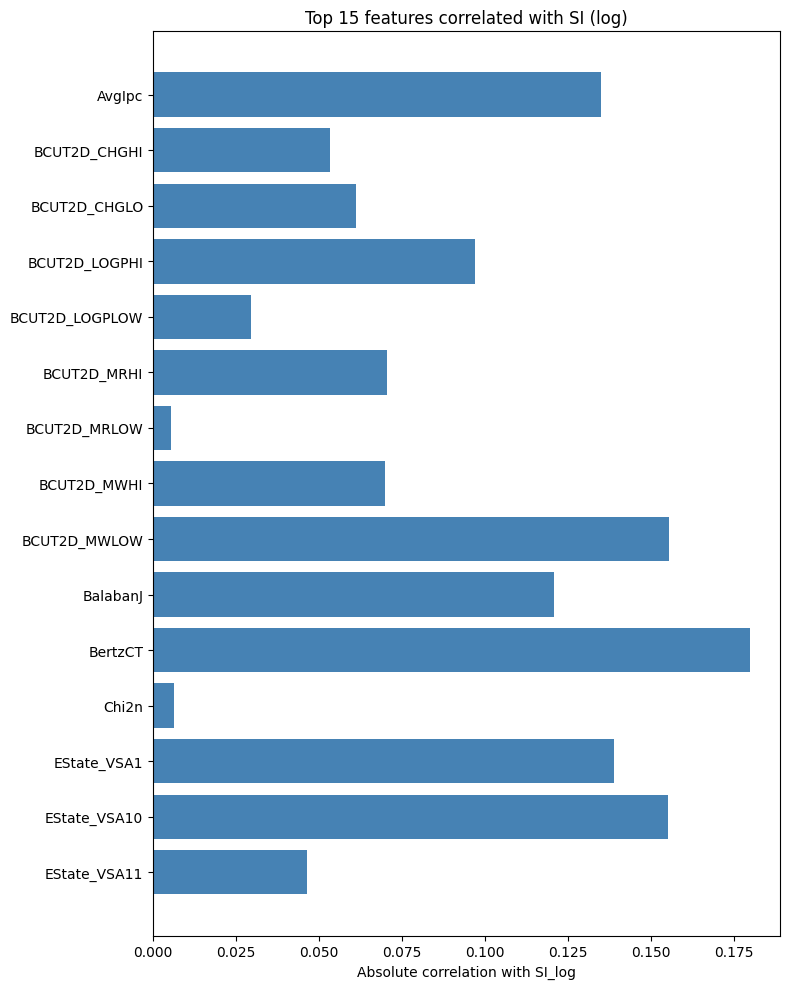

In [8]:
target_corr = DataFrame({
    "IC50_log": X_filtered.corrwith(df["IC50, mM_log"]).abs().sort_values(ascending = False),
    "CC50_log": X_filtered.corrwith(df["CC50, mM_log"]).abs().sort_values(ascending = False),
    "SI_log": X_filtered.corrwith(df["SI_log"]).abs().sort_values(ascending = False)
})

print("Top 10 features by correlation with each target:")
print(target_corr.head(10))

fig, ax = plt.subplots(figsize = (8, 10))
ax.barh(target_corr.index[:15][::-1], target_corr["SI_log"].head(15)[::-1], color = "steelblue")
ax.set_xlabel("Absolute correlation with SI_log")
ax.set_title("Top 15 features correlated with SI (log)")
plt.tight_layout()
plt.savefig("graphs/feature_target_corr.png", dpi = 150)
plt.show()

Итого:

- распределения таргетов были очень сильно смещены к нулю, заменили их на логарифмы
  - skew для `IC50` стал почти нулевым
  - для двух других таргетов skew остатётся довольно значимым, потенциально можно улучшить модели, поработав тут больше с преобразованиями

- произведён анализ корреляции признаков между собой и с таргетами:
  - убраны $34$ признака с низкой дисперсией (почти константые), почти не несут информации, но могут вызывать сингулярности в матрицах дальше при обучении
  - убраны $33$ высококоррелированных признака: мультиколлинеарность увеличивает дисперсию оценок коэффициентов и ухудшает численную стабильность
  - корреляции признаков с таргетом остались в диапазоне $0.01-0.2$, нет сильных зависимостей признак -> таргет, сходу не видно утечки таргета в данные